In [1]:
import yfinance as yf

# Baixando o histórico da ação da Petrobras dos últimos 6 meses
dados = yf.download("PETR4.SA", period="6mo")

# Exibindo as primeiras linhas da tabela
dados.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2025-10-10,29.023386,29.236650,28.955529,29.178487,50214400
2025-10-13,29.304506,29.343283,29.052466,29.226956,13890500
2025-10-14,29.100937,29.527465,28.965222,29.033080,28138200
2025-10-15,28.839203,29.246345,28.761652,29.130018,40261000
2025-10-16,28.548388,28.897365,28.509611,28.829508,28660900


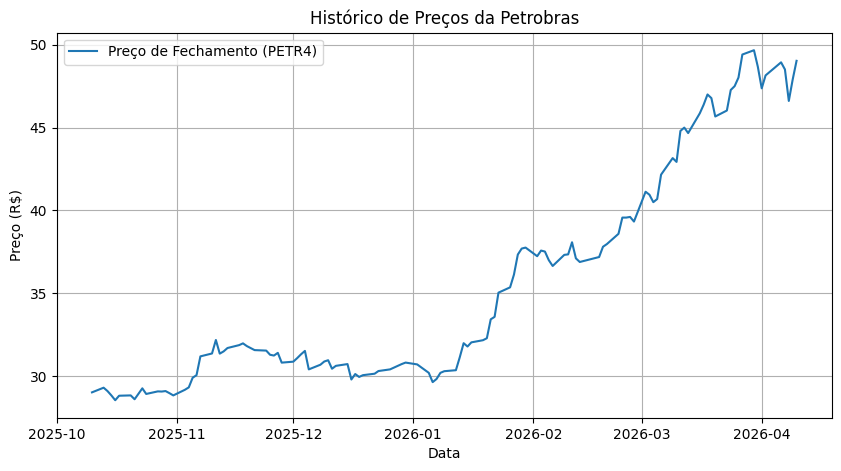

In [2]:
import matplotlib.pyplot as plt

# Desenhando o gráfico do preço de fechamento (Close)
plt.figure(figsize=(10, 5))
plt.plot(dados.index, dados['Close'], label='Preço de Fechamento (PETR4)')
plt.title('Histórico de Preços da Petrobras')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Separando as pistas (X) e o alvo (y)
X = dados[['Open', 'High', 'Low', 'Volume']]
y = dados['Close']

print("Formato do X:", X.shape)
print("Formato do y:", y.shape)

Formato do X: (123, 4)
Formato do y: (123, 1)


In [9]:
from sklearn.model_selection import train_test_split

# Dividindo os dados: 80% para treino e 20% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Dias usados para treinar:", X_treino.shape[0])
print("Dias usados para testar:", X_teste.shape[0])

Dias usados para treinar: 97
Dias usados para testar: 25


In [10]:
from sklearn.linear_model import LinearRegression

# 1. Criando o modelo
modelo = LinearRegression()

# 2. Treinando o modelo com os dados do passado (treino)
modelo.fit(X_treino, y_treino)

# 3. Pedindo para o modelo prever os preços da parte de teste
previsoes = modelo.predict(X_teste)

print("Previsões feitas com sucesso!")

Previsões feitas com sucesso!


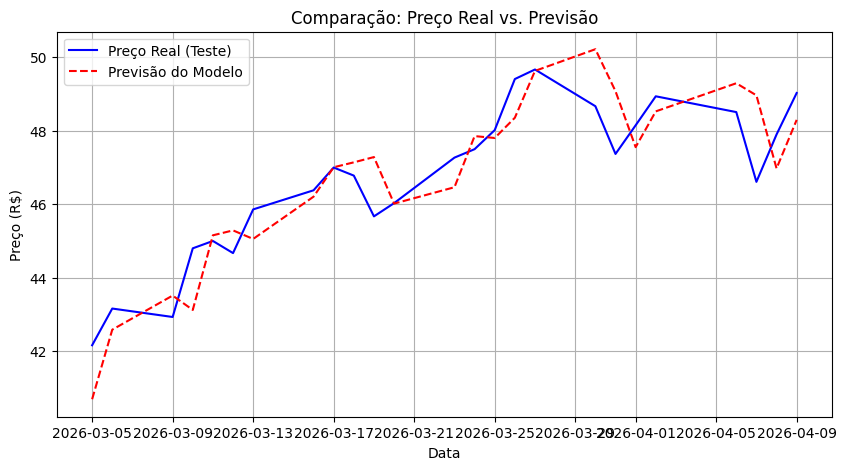

In [11]:
# Criando um gráfico para comparar Real x Previsto
plt.figure(figsize=(10, 5))
plt.plot(y_teste.index, y_teste.values, label='Preço Real (Teste)', color='blue')
plt.plot(y_teste.index, previsoes, label='Previsão do Modelo', color='red', linestyle='--')
plt.title('Comparação: Preço Real vs. Previsão')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error

# Calculando a média de erro em Reais
erro_medio = mean_absolute_error(y_teste, previsoes)
print(f"Erro Absoluto Médio: R$ {erro_medio:.2f}")

Erro Absoluto Médio: R$ 0.78


In [8]:
# Trazendo o preço de fechamento de "amanhã" para a linha de "hoje"
dados['Alvo'] = dados['Close'].shift(-1)

# Como o último dia do dataset não tem um "amanhã", a linha dele ficará com um valor vazio (NaN). Vamos apagar as linhas vazias:
dados = dados.dropna()

# Agora nossas pistas (X) são as informações do dia atual. Podemos até incluir o fechamento de hoje!
X = dados[['Open', 'High', 'Low', 'Volume', 'Close']]

# Nosso alvo (y) agora é estritamente o preço do dia seguinte
y = dados['Alvo']